# Florida school assessment results — merge & investigate

**Source.** 231 school-level workbooks from the FLDOE K-12 assessment results
pages, spring administrations **2015–2026** (no 2020 — no spring testing),
fetched with `python -m src.cli florida data assessments fetch` into
`data/florida/assessments/raw/<year>/`. Each year has 21 files: ELA grades
3–10, Mathematics grades 3–8, Statewide Science grades 5 & 8, and the five
End-of-Course exams (Algebra 1, Geometry, Biology 1, Civics, U.S. History).
See [`docs/data/florida/README.md`](../../../docs/data/florida/README.md) for
the download provenance and per-year `SOURCE_MANIFEST.tsv`.

**Why these files.** They are the achievement outcome for the downstream
barrier-construction event study: an annual, school-level panel of test results
running back to the mid-1990s. The alternatives were rejected — SEDA v6 pools
2009–2019 with no annual dimension, and the federal EDFacts panel is kept only
as a robustness cross-check.

**What this notebook is.** A descriptive pass over the merged assessment panel —
tables and plots only. It parses every workbook into one tidy
`school × year × subject × grade` frame *in memory* and then characterises it:
layout and merge validation, achievement-level consistency, suppression, panel
shape, the test-regime scale breaks, and the within-`year × subject × grade`
z-score of the school mean. **It writes no files.** Turning the parser into a
persisted table is the future `florida data assessments preprocess` step.

**Out of scope — the `schools` module.** This notebook never leaves the
assessment files. No geocoding, no `NCESSCH` / NCES EDGE coordinates, no FLDOE
MSID master-file join, no coverage judgement against the Florida school
*universe*, no "regular school" filter. The only key here is the FLDOE
**District + School number** (`msid`, 6 chars).

Final-panel-level stats — the outcome distribution, covariate/treatment structure after joining to schools and barriers — now live in [`output/notebooks/descriptive_statistics.ipynb`](../../../output/notebooks/florida/descriptive_statistics.ipynb). The subject/grade-level panel-shape analysis below stays here since it's what motivates the z-score construction in §4.

### What an FLDOE school-results file contains

Each workbook is one **spring administration × subject × grade** (EOC files pool
all grades into one sheet). A data row is a school; the columns this notebook
keeps are:

| column | meaning |
|---|---|
| `mean_scale_score` | the school's mean student **scale score** — the headline achievement metric. Its numeric range is fixed by the test: e.g. ≈ 240–412 across FSA ELA/Math grades, ≈ 200 on Statewide Science, ≈ 425–575 on the FSA EOCs — and a *different* range again on FAST / B.E.S.T. from 2023 on. |
| `pct_level3_plus` | percent of the school's students at **Achievement Level 3 or above** — Florida's "satisfactory / on grade level" bar. Levels run 1 (lowest) to 5. |
| `pct_l1 … pct_l5` | percent of students in each of the five levels (sums to ≈ 100). |
| `n_students` | number of students tested. Drives the small-cell **suppression** rule (`n < 10`, sometimes `< 20`), which blanks every score column for that row while leaving `n_students` visible. |

The event-study outcome will be `mean_scale_score`, made comparable across the
regime breaks by standardising it within each `year × subject × grade`
(section 4). `pct_level3_plus` is a coarser fallback: it is always in
"percent past a fixed bar" units, but the bar itself was re-set at each regime
change.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110
BLUE, RED, GREY = "#4C78A8", "#E45756", "#B0B0B0"


def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = repo_root()
if str(ROOT) not in sys.path:            # so `import src...` works from the notebook dir
    sys.path.insert(0, str(ROOT))
RAW = ROOT / "data/florida/assessments/raw"
print("raw:", RAW, "\nyears:", sorted(p.name for p in RAW.glob("[0-9]" * 4)))

raw: /Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/florida/assessments/raw 
years: ['2015', '2016', '2017', '2018', '2019', '2021', '2022', '2023', '2024', '2025', '2026']


## 1. Parse & merge

**Two on-disk layouts** across the 231 files, and the parser has to absorb both:

* **wide-standard** — ELA / Math grade files, every EOC file, and Statewide
  Science from 2024 on. The header row holds `District Number, District Name,
  School Number, School Name, [Grade,] Number of Students, Mean Scale Score,
  Percentage in Level 3 or Above, 1..5`.
* **science-legacy** — Statewide Science 2015–2023. `Grade` comes *first*, the
  `1..5` columns come *before* the "% Level 3 and above" column, there are
  trailing "Mean Points Earned by Content Area" columns, and a
  "Number of Points Possible" row sits directly under the header.

Rather than special-casing per file, the parser (1) finds the header row by
looking for `District Number` + `School Number`, (2) maps each header cell to a
canonical name and drops the rest (content-area sub-scores, blank spacer
columns), and (3) keeps only rows whose District and School numbers parse as
integers — which quietly discards the "points possible" row and the trailing
footnote lines. Every file's first surviving row is `STATE TOTALS`
(`msid == "000000"`), kept and flagged rather than dropped: it is the statewide
reference line the plots lean on.

This parser is not defined here — it lives in
[`src/regions/florida/sources/assessments/preprocess.py`](../../regions/florida/sources/assessments/preprocess.py)
and is what `python -m src.cli florida data assessments preprocess` runs. This
notebook imports it, builds the same in-memory frame, and investigates it; the
CLI step additionally computes the z-score and writes
`data/florida/assessments/processed/assessments.parquet`. `parse_workbook`
returns `year, subject, grade, district_number, district_name, school_number,
school_name, msid, is_state_total, suppressed` plus the eight score columns.

In [2]:
from src.regions.florida.sources.assessments.preprocess import (
    SCORE_COLS, SUBJECT_LABEL, iter_raw_files, parse_workbook, regime,
)

In [3]:
frames = [parse_workbook(p, y, s, g) for p, y, s, g in iter_raw_files()]
raw_long = pd.concat(frames, ignore_index=True)

n_files = raw_long["source_file"].nunique()
print(f"parsed {n_files} files -> {len(raw_long):,} rows "
      f"({int(raw_long.is_state_total.sum())} state-total rows)")
assert n_files == 231 and raw_long.is_state_total.sum() == 231
raw_long.head()

parsed 231 files -> 371,122 rows (231 state-total rows)


,year,subject,grade,district_number,district_name,school_number,school_name,msid,is_state_total,suppressed,n_students,mean_scale_score,pct_level3_plus,pct_l1,pct_l2,pct_l3,pct_l4,pct_l5,source_file
0,2015,ALG1,EOC,00,STATE TOTALS,0000,FSA ALGEBRA 1 EOC STATE TOTALS,000000,True,False,201745,497,56,31,14,30,14,11,FL2015_ALG1_EOC_spring_school.xls
1,2015,ALG1,EOC,01,ALACHUA,0052,A.QUINN JONES/EXCEP.STUD.CTR.,010052,False,True,5,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,FL2015_ALG1_EOC_spring_school.xls
2,2015,ALG1,EOC,01,ALACHUA,0112,ABRAHAM LINCOLN MIDDLE SCHOOL,010112,False,False,138,536,93,4,2,14,13,66,FL2015_ALG1_EOC_spring_school.xls
3,2015,ALG1,EOC,01,ALACHUA,0121,HOWARD W. BISHOP MIDDLE SCHOOL,010121,False,False,90,524,91,6,3,24,29,38,FL2015_ALG1_EOC_spring_school.xls
4,2015,ALG1,EOC,01,ALACHUA,0141,WESTWOOD MIDDLE SCHOOL,010141,False,False,208,508,65,22,13,23,20,23,FL2015_ALG1_EOC_spring_school.xls


`raw_long` is the union of all 231 files — one row per school per file, plus one
`STATE TOTALS` row per file (231 in total). Nothing has been dropped for
*content* yet: `suppressed` rows are still present (with `NaN` scores), and both
layouts have been flattened to the same columns. The `_to_id` coercion is what
fixed an earlier bug — one 2018 file stored the ID columns as numbers, so
`"01"` arrived as `1` and a naive string filter silently deleted every
low-numbered school.

### Derived columns

* `subject_label` — a readable subject name for plot legends.
* `regime` — the scoring system in force, the single most important grouping in
  this notebook. **FSA** (2015–22) → **FAST** (2023–) for ELA / Math; **FSA** →
  **B.E.S.T.** (2023–) for Algebra 1 / Geometry; **NGSSS Science** and
  **NGSSS EOC** (Biology 1, Civics, U.S. History) run unbroken the whole period.
  Scale scores are comparable **only within a `regime × subject × grade`**.
* `retrofitted_2015` — 2015 FSA results were released before achievement levels
  existed (the cut scores were adopted in January 2016 and applied backward),
  hence the "reported as percentile scores" note in those files. Flagged so
  section 3 can test whether the 2015 scale nonetheless lines up with 2016+.
* `cell` — the `year|subject|grade` key that every consistency check and every
  standardisation groups on.

`subject_label` and `regime` are imported from the `preprocess` module so the
notebook and the CLI step agree by construction.

In [4]:
df = raw_long.copy()
df["subject_label"] = df["subject"].map(SUBJECT_LABEL)
df["regime"] = [regime(y, s) for y, s in zip(df.year, df.subject)]
df["retrofitted_2015"] = (df.year == 2015) & df.subject.isin(["ELA", "MATH", "ALG1", "GEO"])
df["cell"] = df.year.astype(str) + "|" + df.subject + "|" + df.grade

state = df[df.is_state_total].copy()
school = df[~df.is_state_total].copy()
print(f"school rows: {len(school):,}   state rows: {len(state)}   "
      f"distinct schools (msid): {school.msid.nunique():,}")
school.groupby(["subject", "regime"]).size().unstack("regime", fill_value=0)

school rows: 370,891   state rows: 231   distinct schools (msid): 4,419


regime,B.E.S.T.,FAST,FSA,NGSSS EOC,NGSSS Science
subject,,,,,
ALG1,7573,0,12049,0,0
BIO1,0,0,0,12980,0
CIVICS,0,0,0,13763,0
ELA,0,52257,86502,0,0
GEO,6739,0,10478,0,0
MATH,0,45329,74282,0,0
SCI,0,0,0,0,39055
USHIST,0,0,0,9884,0


In [5]:
# numeric summary of the reported (non-suppressed) school rows
school.loc[~school.suppressed, SCORE_COLS].describe().round(1)

,n_students,mean_scale_score,pct_level3_plus,pct_l1,pct_l2,pct_l3,pct_l4,pct_l5
count,332774.0,332778.0,332778.0,332778.0,332778.0,332778.0,332778.0,332778.0
mean,137.4,307.3,54.8,23.7,21.4,24.5,18.2,12.1
std,126.6,81.5,22.2,18.0,9.3,9.3,10.3,12.7
min,10.0,148.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,59.0,230.0,39.0,10.0,16.0,19.0,11.0,3.0
50%,98.0,312.0,55.0,20.0,22.0,24.0,18.0,8.0
75%,163.0,337.0,71.0,33.0,27.0,30.0,25.0,17.0
max,1715.0,559.0,100.0,99.0,88.0,95.0,91.0,99.0


This pooled summary deliberately mixes scales (FSA ELA ≈ 300, Science ≈ 200,
EOC ≈ 500, FAST ≈ 230), so the combined mean and SD carry no meaning — read it
only as a **range check**: counts non-negative, every percentage inside 0–100,
`mean_scale_score` never absurd, no all-`NaN` column. Regime-specific summaries
follow in section 3.

## 2. Validate the merge

Four checks, each targeting a specific way the parse could have gone wrong:

1. **Do `pct_l1..pct_l5` sum to ~100?** — confirms those five columns were
   mapped correctly. The science-legacy layout orders them differently, so a
   position-based reader would scramble them here.
2. **Does `pct_l3 + pct_l4 + pct_l5` equal the reported `pct_level3_plus`?** —
   confirms the "% Level 3 or above" column is really that, and not a
   "% Level 2+" or a content-area sub-score sitting in the same position.
3. **Is `(year, subject, grade, msid)` unique?** — the merge key; a school must
   appear once per cell.
4. **Are the district numbers plausible?** — the check that surfaced the
   numeric-ID bug above.

L1..L5 sum within [98,102]: 1.0000   (range 98-102)
|(L3+L4+L5) - reported %L3+|  <= 1: 1.0000   (max 1)


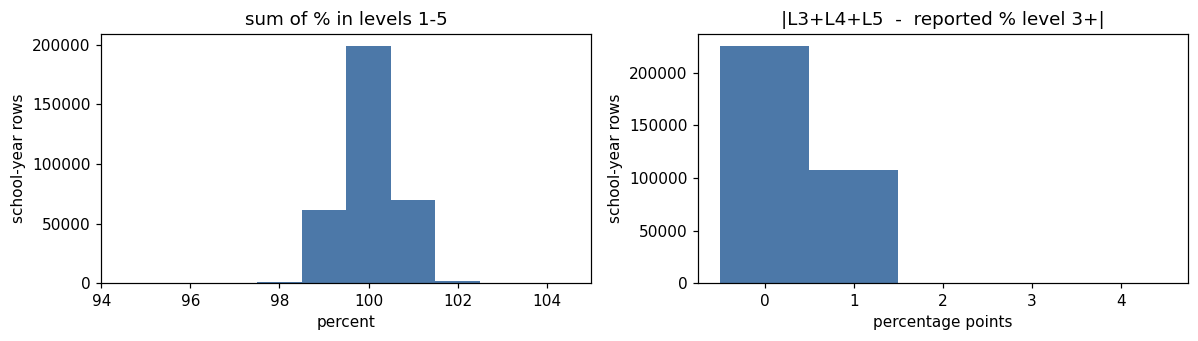

In [6]:
# achievement-level internal consistency (non-suppressed school rows)
ok = school[~school.suppressed]
lv_sum = ok[["pct_l1", "pct_l2", "pct_l3", "pct_l4", "pct_l5"]].sum(axis=1)
l3p_gap = (ok.pct_l3 + ok.pct_l4 + ok.pct_l5 - ok.pct_level3_plus).abs()
print("L1..L5 sum within [98,102]: %.4f   (range %.0f-%.0f)"
      % (lv_sum.between(98, 102).mean(), lv_sum.min(), lv_sum.max()))
print("|(L3+L4+L5) - reported %%L3+|  <= 1: %.4f   (max %.0f)"
      % ((l3p_gap <= 1).mean(), l3p_gap.max()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(lv_sum, bins=range(95, 106), align="left", color=BLUE)
ax[0].set_title("sum of % in levels 1-5"); ax[0].set_xlabel("percent")
ax[1].hist(l3p_gap, bins=range(0, 6), align="left", color=BLUE)
ax[1].set_title("|L3+L4+L5  -  reported % level 3+|"); ax[1].set_xlabel("percentage points")
for a in ax:
    a.set_ylabel("school-year rows")
plt.tight_layout(); plt.show()

Both checks pass for 100% of non-suppressed school rows — the histograms sit
entirely on 100 and on 0. The `±2` / `±1` slack is FLDOE's own rounding; the
note at the top of every workbook says "percentages may not add to 100 due to
rounding". The column mapping is therefore trustworthy in both layouts.

In [7]:
# duplicate keys & district sanity
dup = school.groupby(["year", "subject", "grade", "msid"]).size()
print("duplicate (year, subject, grade, msid) keys:", int((dup > 1).sum()))

dd = (school.groupby("district_number")
      .agg(name=("district_name", "first"), rows=("msid", "size"),
           schools=("msid", "nunique")))
print(f"\ndistinct districts: {len(dd)}   number range {dd.index.min()}-{dd.index.max()}")
print("non-county district numbers (>= 68):")
dd[dd.index >= "68"]

duplicate (year, subject, grade, msid) keys: 0

distinct districts: 77   number range 01-82
non-county district numbers (>= 68):


,name,rows,schools
district_number,,,
68,DEAF/BLIND,471,6
71,FL VIRTUAL,282,5
72,FAU LAB SCH,373,2
73,FSU LAB SCH,307,2
74,FAMU LAB SCH,226,1
75,UF LAB SCH,215,1
78,STATE COLLEGES,41,17
80,COMM COLLEGE,285,11
81,TCC CHARTER,29,2


No duplicate keys. Florida has 67 county districts plus a handful of
**state-operated "districts"**: the university lab schools (FAU / FSU / FAMU /
UF), the Florida School for the Deaf and the Blind (68), Florida Virtual School
(71), and college / charter authorisers numbered in the 70s–80s. These are
legitimate and carry real schools that belong in the panel; their `msid`s keep
the same 2-digit + 4-digit shape.

overall suppressed share of school rows: 0.103


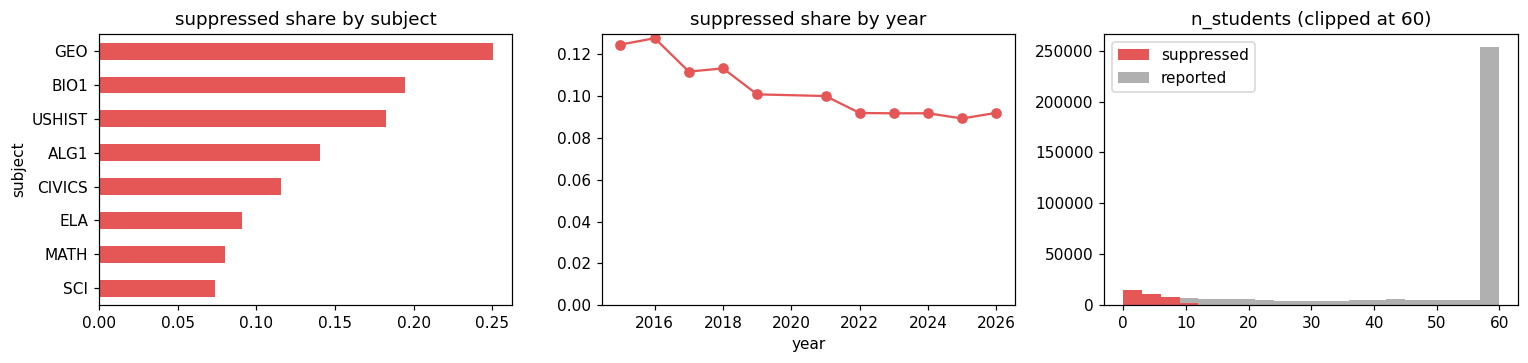

cells (year x subject x grade) with > 25% rows suppressed: 6 / 231


In [8]:
# suppression — a small-cell rule (n < 10, sometimes < 20)
print("overall suppressed share of school rows: %.3f" % school.suppressed.mean())
by_sub = school.groupby("subject").suppressed.mean().sort_values()
by_year = school.groupby("year").suppressed.mean()

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
by_sub.plot.barh(ax=ax[0], color=RED); ax[0].set_title("suppressed share by subject")
by_year.plot(ax=ax[1], marker="o", color=RED); ax[1].set_title("suppressed share by year")
ax[1].set_ylim(0, None)
ns = school.dropna(subset=["n_students"])
ax[2].hist([ns.loc[ns.suppressed, "n_students"].clip(upper=60),
            ns.loc[~ns.suppressed, "n_students"].clip(upper=60)],
           bins=range(0, 62, 3), stacked=True, label=["suppressed", "reported"],
           color=[RED, GREY])
ax[2].set_title("n_students (clipped at 60)"); ax[2].legend()
plt.tight_layout(); plt.show()

cell_supp = school.groupby("cell").suppressed.mean()
print("cells (year x subject x grade) with > 25%% rows suppressed: %d / %d"
      % ((cell_supp > 0.25).sum(), len(cell_supp)))

Suppression is **not missing-at-random**: the third panel shows suppressed rows
sitting almost entirely below `n ≈ 20`, and the by-subject bars show it
concentrated in the lower-enrolment EOCs. Two consequences for the event study —
a school can move in and out of the estimation sample as a grade cohort crosses
the threshold year to year, and the schools that vanish are disproportionately
small, rural and alternative. The six `year × subject × grade` cells that lose
more than a quarter of their rows are all small EOC cohorts.

### Panel shape — assessment files only

How many schools report each `subject × year` cell, and how stable that set is
over time. This is **not** a coverage statement about the Florida school
universe (which schools exist, where, when they opened / closed — that needs the
directory, i.e. the `schools` module). It only describes the internal shape of
the merged panel, so section 4's z-scores and any event study know what they
stand on.

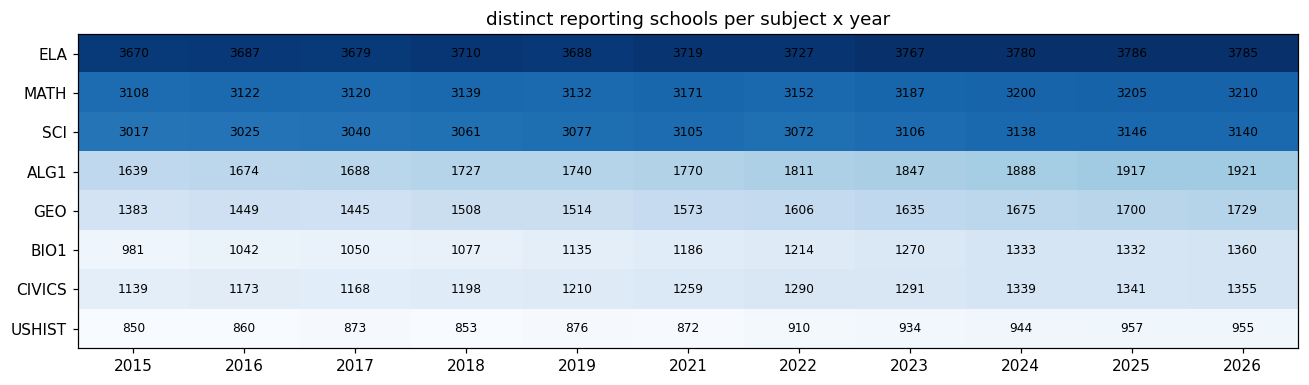

year,2015,2016,2017,2018,2019,2021,2022,2023,2024,2025,2026
subject,,,,,,,,,,,
ELA,3670,3687,3679,3710,3688,3719,3727,3767,3780,3786,3785
MATH,3108,3122,3120,3139,3132,3171,3152,3187,3200,3205,3210
SCI,3017,3025,3040,3061,3077,3105,3072,3106,3138,3146,3140
ALG1,1639,1674,1688,1727,1740,1770,1811,1847,1888,1917,1921
GEO,1383,1449,1445,1508,1514,1573,1606,1635,1675,1700,1729
BIO1,981,1042,1050,1077,1135,1186,1214,1270,1333,1332,1360
CIVICS,1139,1173,1168,1198,1210,1259,1290,1291,1339,1341,1355
USHIST,850,860,873,853,876,872,910,934,944,957,955


In [9]:
cov = (school.groupby(["subject", "year"]).msid.nunique()
       .unstack("year").reindex(SUBJECT_LABEL))
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.imshow(cov.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(cov.shape[1])); ax.set_xticklabels(cov.columns)
ax.set_yticks(range(cov.shape[0])); ax.set_yticklabels(cov.index)
for (i, j), v in np.ndenumerate(cov.values):
    ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("distinct reporting schools per subject x year")
plt.tight_layout(); plt.show()
cov

ELA and Math reach ~3,100–3,800 schools a year; the EOCs far fewer (U.S. History
< 1,000 — it is a single high-school course). Counts grow gently over the decade
as the school system expands. The next two cells break ELA / Math down by grade
and quantify how much the reporting set churns.

In [10]:
# ELA/Math: reporting schools per grade x year
for subj in ["ELA", "MATH"]:
    g = (school[school.subject == subj].groupby(["grade", "year"]).msid.nunique()
         .unstack("year"))
    print(f"\n{subj} — reporting schools per grade x year")
    print(g.to_string())


ELA — reporting schools per grade x year
year   2015  2016  2017  2018  2019  2021  2022  2023  2024  2025  2026
grade                                                                  
03     2230  2242  2270  2277  2282  2324  2333  2356  2374  2362  2375
04     2207  2238  2241  2276  2273  2334  2321  2359  2362  2365  2359
05     2228  2239  2254  2277  2283  2344  2333  2363  2367  2372  2371
06     1249  1264  1271  1315  1309  1339  1334  1377  1391  1402  1419
07     1157  1179  1195  1230  1229  1266  1298  1307  1324  1337  1348
08     1168  1185  1203  1252  1242  1284  1299  1320  1338  1361  1366
09      912   897   895   915   889   892   909   943   956   966   948
10      841   860   862   893   866   885   912   924   945   951   949

MATH — reporting schools per grade x year
year   2015  2016  2017  2018  2019  2021  2022  2023  2024  2025  2026
grade                                                                  
03     2229  2242  2264  2278  2275  2329  2314  23

In [11]:
# schools present in every year, and year-to-year entry / exit (ELA)
def present_all(sub):
    yrs = sorted(sub.year.unique())
    per = sub.groupby("msid").year.nunique()
    return int((per == len(yrs)).sum()), int(per.size), len(yrs)

for subj in ["ELA", "MATH", "SCI", "ALG1", "BIO1"]:
    sub = school[school.subject == subj]
    if subj in ("ELA", "MATH"):
        sub = sub[sub.grade == "05"]
    n_all, n_any, ny = present_all(sub)
    print(f"{subj:6s}: {n_all:4d} schools in all {ny} years, {n_any:4d} ever")

ela = school[school.subject == "ELA"]
seen = {y: set(g.msid) for y, g in ela.groupby("year")}
yrs = sorted(seen)
churn = pd.DataFrame(
    [(f"{a}->{b}", len(seen[b] - seen[a]), len(seen[a] - seen[b]))
     for a, b in zip(yrs, yrs[1:])],
    columns=["transition", "entered", "left"])
print()
print(churn.to_string(index=False))

ELA   : 1969 schools in all 11 years, 2706 ever


MATH  : 1967 schools in all 11 years, 2702 ever


SCI   : 2589 schools in all 11 years, 3635 ever
ALG1  : 1327 schools in all 11 years, 2351 ever
BIO1  :  731 schools in all 11 years, 1891 ever



transition  entered  left
2015->2016       77    60
2016->2017       73    81
2017->2018      100    69
2018->2019       64    86
2019->2021      116    85
2021->2022       66    58
2022->2023       84    44
2023->2024       63    50
2024->2025       61    55
2025->2026       64    65


About 1,900 schools report ELA in **every** year 2015–2026, while ~2,700 appear
at least once — so roughly a third of the ever-present schools are missing from
at least one year. The 60–120 schools entering or leaving each transition are
real openings, closures and grade-configuration changes. The panel is
**unbalanced**; a staggered-adoption event study has to model entry / exit
rather than assume a fixed roster.

## 3. Test-regime scale breaks

Scale scores are comparable **only within a `regime × subject × grade`**. FSA
(2015–22) → FAST (2023– ) for ELA / Math; FSA → B.E.S.T. (2023– ) for Algebra 1
/ Geometry. The NGSSS EOCs (Biology 1, Civics, U.S. History) and Statewide
Science were never rescaled and should run flat through 2023→2024. In every
plot below the **shaded band marks 2023–2026**, the FAST / B.E.S.T. years.

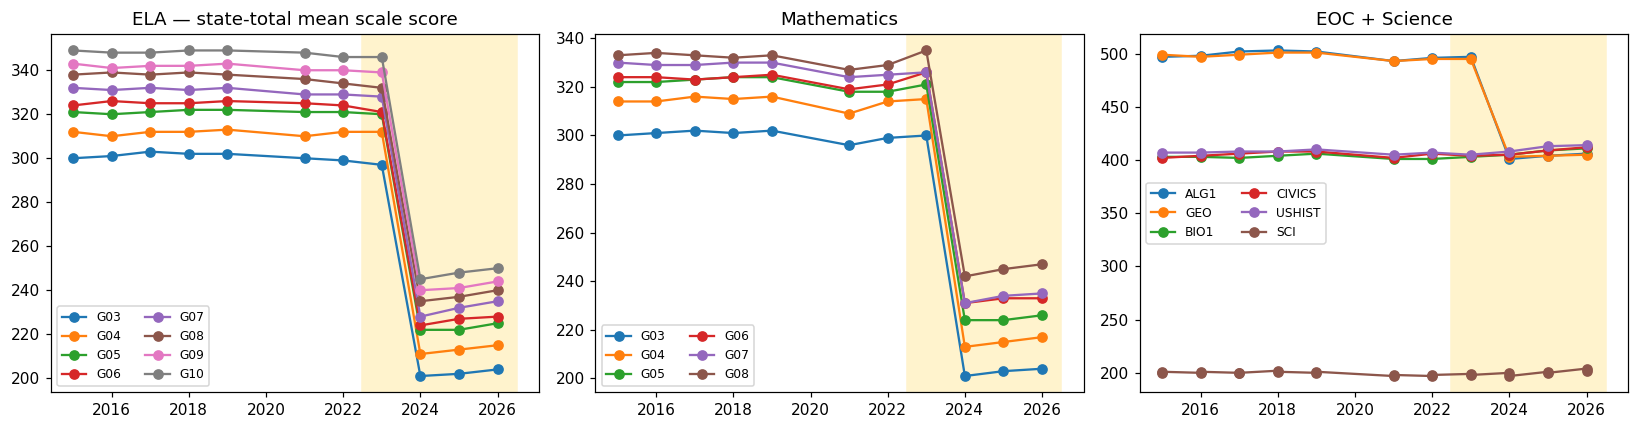

In [12]:
piv = state.pivot_table(index="year", columns=["subject", "grade"], values="mean_scale_score")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for g in piv["ELA"].columns:
    axes[0].plot(piv.index, piv[("ELA", g)], marker="o", label=f"G{g}")
axes[0].set_title("ELA — state-total mean scale score"); axes[0].legend(ncol=2, fontsize=8)
for g in piv["MATH"].columns:
    axes[1].plot(piv.index, piv[("MATH", g)], marker="o", label=f"G{g}")
axes[1].set_title("Mathematics"); axes[1].legend(ncol=2, fontsize=8)
for subj in ["ALG1", "GEO", "BIO1", "CIVICS", "USHIST", "SCI"]:
    col = state[state.subject == subj].set_index("year").mean_scale_score
    axes[2].plot(col.index, col.values, marker="o", label=subj)
axes[2].set_title("EOC + Science"); axes[2].legend(ncol=2, fontsize=8)
for a in axes:
    a.axvspan(2022.5, 2026.5, color="#FFF3CD", zorder=0)
plt.tight_layout(); plt.show()

ELA and Math fall ~100 scale points at 2023 — that is the FAST rescaling, not a
collapse in learning. Algebra 1 / Geometry step down similarly (FSA→B.E.S.T.).
Biology 1, Civics, U.S. History and Statewide Science carry straight through
2023 on one line because their scales were left alone. Within a regime the state
means are near-flat, drifting a point or two a year (2021 dips slightly — the
post-COVID year).

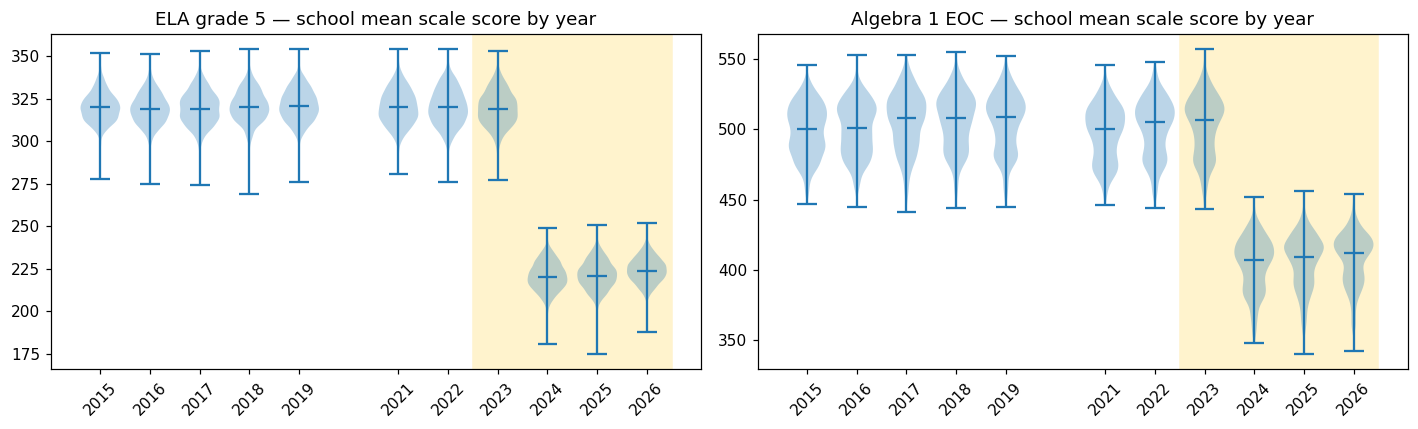

In [13]:
# school-level spread, not just the mean: distribution of school means by year
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (subj, grd, lab) in zip(
        axes, [("ELA", "05", "ELA grade 5"), ("ALG1", "EOC", "Algebra 1 EOC")]):
    sub = school[(school.subject == subj) & (school.grade == grd) & ~school.suppressed]
    yrs = sorted(sub.year.unique())
    ax.violinplot([sub.loc[sub.year == y, "mean_scale_score"].values for y in yrs],
                  positions=yrs, widths=0.8, showmedians=True)
    ax.axvspan(2022.5, 2026.5, color="#FFF3CD", zorder=0)
    ax.set_title(f"{lab} — school mean scale score by year"); ax.set_xticks(yrs)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

The violins show that at a regime change the **whole school distribution
translates**, while its width barely moves. That is exactly the situation a
within-cell z-score is built for: standardising removes a location-plus-scale
shift and leaves each school's position relative to its peers intact.

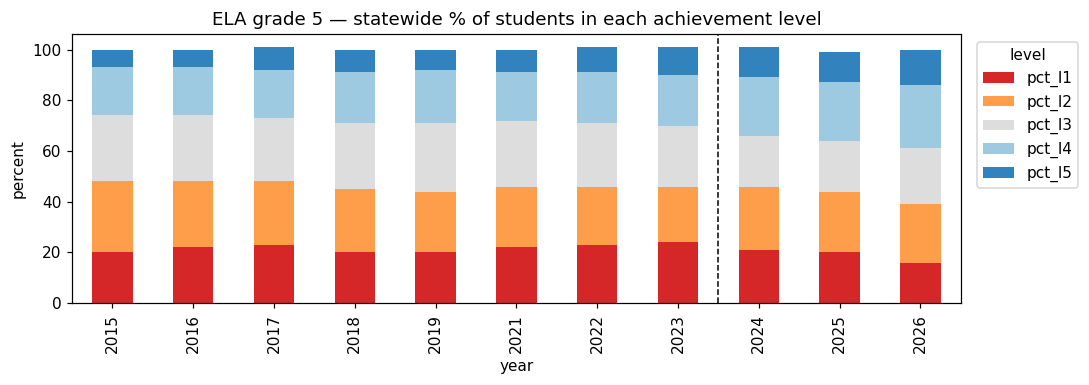

,pct_l1,pct_l2,pct_l3,pct_l4,pct_l5
year,,,,,
2015,20,28,26,19,7
2016,22,26,26,19,7
2017,23,25,25,19,9
2018,20,25,26,20,9
2019,20,24,27,21,8
2021,22,24,26,19,9
2022,23,23,25,20,10
2023,24,22,24,20,11
2024,21,25,20,23,12


In [14]:
# achievement-level composition over time (state totals) — ELA grade 5
comp = (state[(state.subject == "ELA") & (state.grade == "05")]
        .set_index("year")[["pct_l1", "pct_l2", "pct_l3", "pct_l4", "pct_l5"]])
ax = comp.plot(kind="bar", stacked=True, figsize=(10, 3.6),
               color=["#D62728", "#FF9E4A", "#DDDDDD", "#9ECAE1", "#3182BD"])
ax.set_title("ELA grade 5 — statewide % of students in each achievement level")
ax.set_ylabel("percent"); ax.legend(title="level", bbox_to_anchor=(1.01, 1))
ax.axvline(7.5, color="k", lw=1, ls="--")   # FSA | FAST boundary (2022 | 2023)
plt.tight_layout(); plt.show()
comp

The level mix is **re-based at each regime change by design** — FLDOE sets the
new cut scores so the statewide level distribution is roughly preserved, which
is why these bars do not jump the way the scale score does at the dashed
FSA | FAST line. That makes `pct_level3_plus` the more transportable of the two
raw metrics — but its cut score is still a *different test's* cut score before
and after 2023, so it is not clean either.

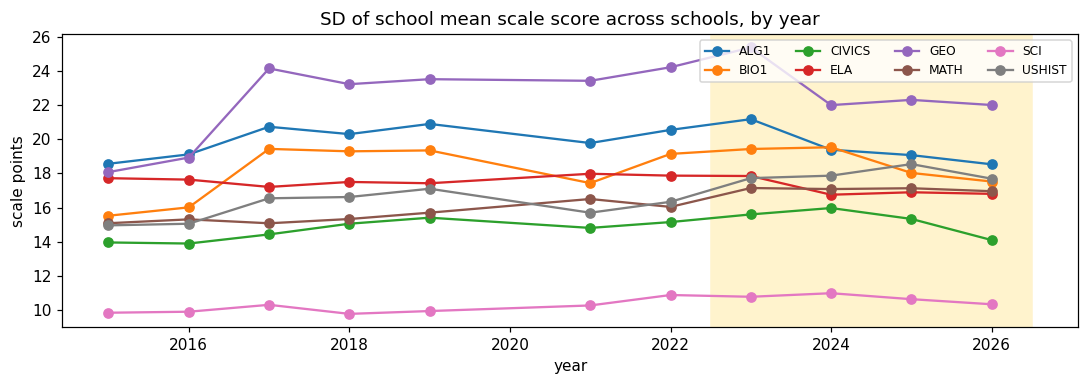

In [15]:
# dispersion across schools by year — the level shifts, the spread is stable
disp = (school[~school.suppressed].groupby(["subject", "year"]).mean_scale_score.std()
        .unstack("subject"))
ax = disp.plot(marker="o", figsize=(10, 3.6))
ax.set_title("SD of school mean scale score across schools, by year")
ax.set_ylabel("scale points"); ax.axvspan(2022.5, 2026.5, color="#FFF3CD", zorder=0)
ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

Within each subject the cross-school SD stays in a fairly narrow band across all
eleven years, including straight through 2023 (FAST's SD lands close to FSA's,
by construction). Because the spread is stable, the within-cell z-score is
comparable **over time**, not just within one year: `z = +1` means "one
school-SD above the state" in 2016 and in 2025 alike.

### Is the 2015 *retrofitted* FSA on the 2016+ scale?

`docs/data/florida/README.md` carried a caveat that 2015 has "no scale-score
scale of its own" and should be treated as its own break. Test it directly:
compare the 2015 and 2016 school-level distributions grade by grade, and plot
the schools present in both years against the 45° line.

subject grade  mean_2015  mean_2016  d_mean  sd_2015  sd_2016
    ELA    03      299.3      300.3     1.0      9.1      9.3
    ELA    04      310.9      309.0    -1.9      8.5      9.2
    ELA    05      319.8      319.0    -0.8      8.8      9.4
    ELA    06      323.7      324.9     1.2     11.5     10.6
    ELA    07      330.9      329.7    -1.2     11.5     11.4
    ELA    08      336.6      337.0     0.4     11.8     12.4
    ELA    09      340.4      338.8    -1.6     13.8     13.6
    ELA    10      346.0      346.4     0.4     12.9     12.1
   MATH    03      299.5      300.5     1.0      8.9      9.2
   MATH    04      312.7      312.6    -0.1      9.7     10.5
   MATH    05      320.3      320.8     0.5     10.3     10.9
   MATH    06      323.3      323.0    -0.3     12.7     13.0
   MATH    07      328.3      327.2    -1.1     11.7     12.6
   MATH    08      331.7      332.2     0.5     12.3     13.7

max |d_mean| across grades: 1.9 scale points


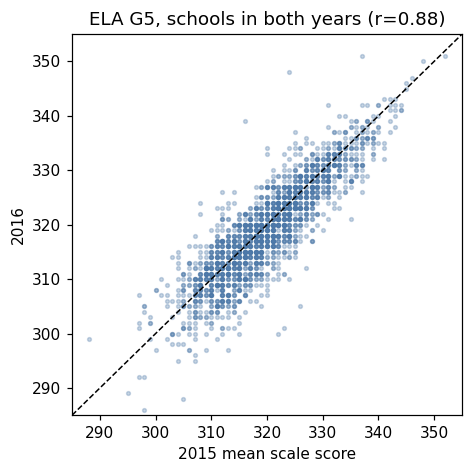

In [16]:
rows = []
for subj in ["ELA", "MATH"]:
    for g in sorted(school[school.subject == subj].grade.unique()):
        a = school.query("year==2015 and subject==@subj and grade==@g and not suppressed")
        b = school.query("year==2016 and subject==@subj and grade==@g and not suppressed")
        rows.append((subj, g, round(a.mean_scale_score.mean(), 1),
                     round(b.mean_scale_score.mean(), 1),
                     round(b.mean_scale_score.mean() - a.mean_scale_score.mean(), 1),
                     round(a.mean_scale_score.std(), 1), round(b.mean_scale_score.std(), 1)))
cmp15 = pd.DataFrame(rows, columns=["subject", "grade", "mean_2015", "mean_2016",
                                    "d_mean", "sd_2015", "sd_2016"])
print(cmp15.to_string(index=False))
print("\nmax |d_mean| across grades: %.1f scale points" % cmp15.d_mean.abs().max())

m = (school.query("subject=='ELA' and grade=='05' and not suppressed")
     .pivot_table(index="msid", columns="year", values="mean_scale_score"))
fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.scatter(m[2015], m[2016], s=6, alpha=.3, color=BLUE)
lo, hi = 285, 355
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("2015 mean scale score"); ax.set_ylabel("2016")
ax.set_title(f"ELA G5, schools in both years (r={m[[2015, 2016]].corr().iloc[0, 1]:.2f})")
plt.tight_layout(); plt.show()

The 2015→2016 shift is a point or two at every grade — the same size as the
2016→2017 wobble — the SDs match, and matched schools sit on the 45° line. So
2015 **pools into the FSA scale** and the README caveat is too strong; the
`retrofitted_2015` flag stays in the frame only for optional robustness checks.
The section-4 z-score is robust to this either way.

## 4. Within `year × subject × grade` z-score

For every `cell = year|subject|grade`, standardise the school mean:

> `z_mss = (mean_scale_score − mean over the cell's schools) / SD over the cell's schools`

`z_mss_w` does the same with the mean and SD **weighted by `n_students`**, which
approximates standardising against the student-level distribution — the
statewide *student* SD is not published, so this is the closest available proxy.
Suppressed rows carry no score and get `NaN`; state-total rows are excluded from
the moments.

This is the construction that makes the outcome usable across the 2023 break: it
subtracts out any per-cell location and scale, so a treated school's post-period
z is measured against its **contemporaneous** peers on whatever test was in
force. The trade-off is that it discards the level of statewide performance —
a common statewide shock in a given year is differenced away — which is
acceptable for a within-Florida event study identified off barrier timing.

per-cell z_mss — mean ~0, sd ~1:
      mean   sd
mean   0.0  1.0
min   -0.0  1.0
max    0.0  1.0


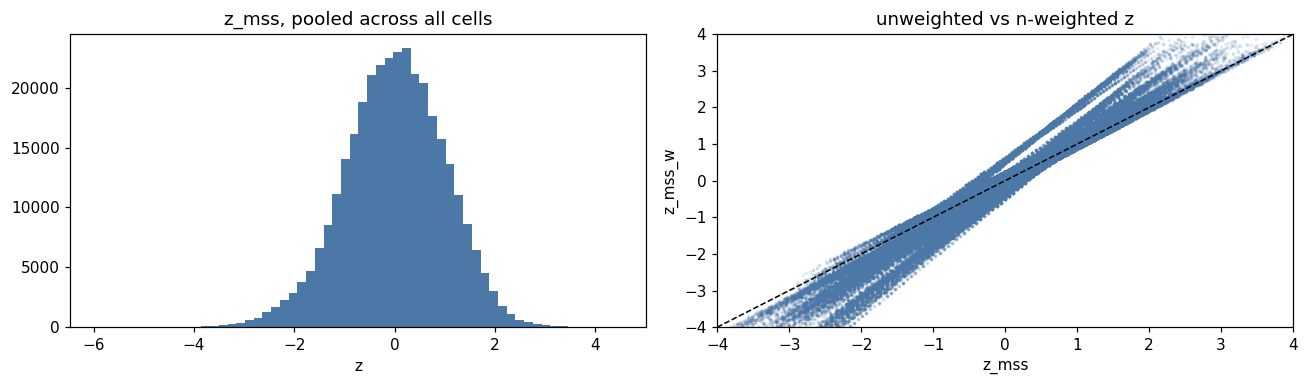

In [17]:
def _z(g: pd.DataFrame) -> pd.DataFrame:
    x = g.mean_scale_score
    z = (x - x.mean()) / x.std()
    w, ok = g.n_students, g.n_students.notna() & x.notna()
    if ok.any() and w[ok].sum() > 0:
        mu = np.average(x[ok], weights=w[ok])
        sd = np.sqrt(np.average((x[ok] - mu) ** 2, weights=w[ok]))
        zw = (x - mu) / sd if sd > 0 else pd.Series(np.nan, index=g.index)
    else:
        zw = pd.Series(np.nan, index=g.index)
    return pd.DataFrame({"z_mss": z, "z_mss_w": zw})


valid = school[~school.suppressed].copy()
school = school.join(valid.groupby("cell", group_keys=False).apply(_z))

chk = (school.dropna(subset=["z_mss"]).groupby("cell")
       .agg(mean=("z_mss", "mean"), sd=("z_mss", "std")))
print("per-cell z_mss — mean ~0, sd ~1:")
print(chk.agg(["mean", "min", "max"]).round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(school.z_mss.dropna(), bins=60, color=BLUE)
ax[0].set_title("z_mss, pooled across all cells"); ax[0].set_xlabel("z")
ax[1].scatter(school.z_mss, school.z_mss_w, s=2, alpha=.1, color=BLUE)
ax[1].plot([-4, 4], [-4, 4], "k--", lw=1)
ax[1].set_xlim(-4, 4); ax[1].set_ylim(-4, 4)
ax[1].set_title("unweighted vs n-weighted z"); ax[1].set_xlabel("z_mss"); ax[1].set_ylabel("z_mss_w")
plt.tight_layout(); plt.show()

Per cell the z-score is mean 0, SD 1 by construction. Pooled across all cells it
is close to standard normal but a touch heavy-tailed and slightly left-skewed —
a handful of very-low-performing alternative schools. Unweighted and weighted z
track closely (points near the 45° line); they diverge most where one large
school pulls the weighted mean, so keep both and let the downstream spec choose.

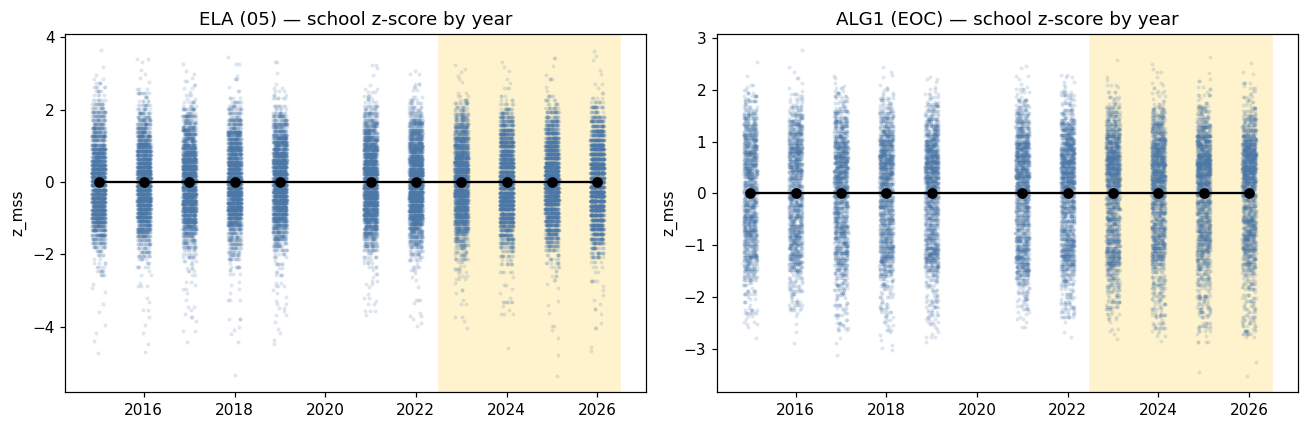

within-school year-to-year change in z_mss:
  mean -0.009   sd 0.475   IQR [-0.28, 0.26]


In [18]:
# the z-score is continuous across the 2023->2024 FAST / B.E.S.T. break
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for (subj, grd), a in zip([("ELA", "05"), ("ALG1", "EOC")], ax):
    sub = school[(school.subject == subj) & (school.grade == grd) & ~school.suppressed]
    a.scatter(sub.year + np.random.uniform(-.15, .15, len(sub)), sub.z_mss,
              s=3, alpha=.12, color=BLUE)
    a.plot(sorted(sub.year.unique()), sub.groupby("year").z_mss.mean().values,
           color="k", marker="o")
    a.axvspan(2022.5, 2026.5, color="#FFF3CD", zorder=0)
    a.set_title(f"{subj} ({grd}) — school z-score by year"); a.set_ylabel("z_mss")
plt.tight_layout(); plt.show()

d = (school.dropna(subset=["z_mss"]).sort_values("year")
     .groupby(["subject", "grade", "msid"]).z_mss.diff())
print("within-school year-to-year change in z_mss:")
print("  mean %.3f   sd %.3f   IQR [%.2f, %.2f]"
      % (d.mean(), d.std(), d.quantile(.25), d.quantile(.75)))

The black line — mean school z by year — sits on ~0 throughout with **no step at
2023**, confirming the standardisation absorbs the regime change; the point
cloud keeps the same vertical spread every year. The usable signal is the
within-school year-to-year change, `Δz_mss`, with SD ≈ 0.47: about half a
school-SD of idiosyncratic movement a year, which is the noise a
barrier-construction effect would have to be detected against.

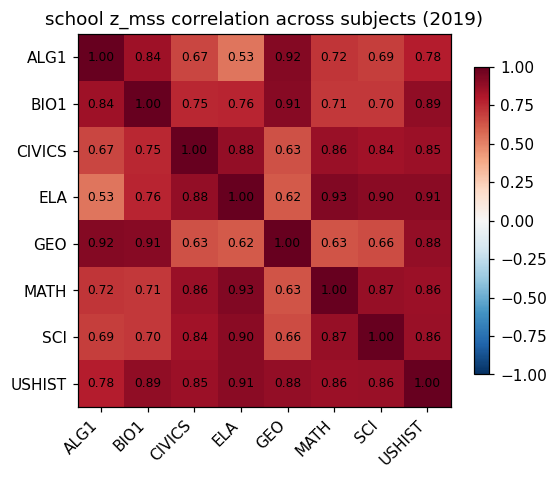

In [19]:
# how do a school's subjects move together? correlation of school z_mss, 2019
w = (school.query("year == 2019 and not suppressed")
     .assign(key=lambda t: np.where(t.grade == "EOC", t.subject, t.subject + t.grade))
     .pivot_table(index="msid", columns="subject", values="z_mss"))
corr = w.corr()
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, shrink=.8); ax.set_title("school z_mss correlation across subjects (2019)")
plt.tight_layout(); plt.show()

Within a year a school's subjects move together but far from perfectly — ELA and
Math z-scores correlate ≈ 0.8, the EOCs less. So the subjects carry partly
independent information: stacking them raises statistical power, and an effect
that turns up in one subject but not the others is a useful placebo / spec
check.

## 5. Summary

* **231 / 231 workbooks parse** into ~371k `school × year × subject × grade`
  rows (≈ 4.4k distinct `msid`), one `STATE TOTALS` row per file. Achievement
  levels sum to 100 (± rounding) and `L3+L4+L5 == reported % level 3+`
  everywhere; no duplicate `(year, subject, grade, msid)` keys. Both on-disk
  layouts (wide-standard, science-legacy) flatten to the same columns.
* **Suppression** blanks the score columns for ≈ 10 % of school rows — an
  `n < 10` (sometimes `< 20`) rule, so it is non-random: it removes small,
  rural and alternative schools, and moves a school in and out of the sample as
  its cohort crosses the threshold. Only 6 / 231 cells lose >25 % of rows.
* **Panel is unbalanced** — ~1.9k schools report ELA every year, ~2.7k ever;
  60–120 enter / leave per year.
* **Regime breaks** are sharp in 2023→2024 for ELA / Math (FSA→FAST) and
  Algebra 1 / Geometry (FSA→B.E.S.T.); Biology 1 / Civics / U.S. History and
  Statewide Science are flat, as expected. The **cross-school SD is stable**
  through the breaks even though the level jumps.
* **2015 retrofitted FSA is on the 2016+ scale** — matched-school 2015↔2016
  means differ by ≤ 1.9 points and sit on the 45° line.
* The **within-`year × subject × grade` z-score** is ~N(0, 1) per cell by
  construction and runs continuously across the scale breaks; within-school
  year-to-year Δz has SD ≈ 0.47 — the variation an event study would use.

**No file is written here.** The harmonised table and the z-score belong in a
`florida data assessments preprocess` step; the `msid → NCESSCH` crosswalk,
coordinates and the open / close + regular-school panel filter belong to
`schools` + `master_file`.